# Data Analytics Using Python — Practice Exercises & Exam Questions

This notebook collects the practice exercises (1–7) with explanations and 10 exam-style questions with solutions and explanations.

In [7]:
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
sns.set(style='whitegrid', context='notebook')
plt.style.use('fivethirtyeight')
print('Libraries ready.')


Libraries ready.


## Exercises 1–7

### Exercise 1: Load a CSV and perform EDA (describe, plots, correlations)
Goal: practice reading data, inspecting structure, plotting distributions, and seeing relationships.
Steps: create a small dataset, write to CSV, read it back, EDA with describe, histograms, scatter, and correlation heatmap.

         Date Region Product  Units  Price
0  2024-01-01  South       A     24  48.05
1  2024-01-02   West       B     21  46.22
2  2024-01-03  North       B     11  41.84
3  2024-01-04  North       B      9  46.61
4  2024-01-05   West       A     16  15.82
Describe:
            Units       Price
count  120.000000  120.000000
mean    19.491667   30.137583
std      4.115958   12.013000
min      9.000000   10.370000
25%     16.000000   19.827500
50%     20.000000   30.035000
75%     22.250000   40.727500
max     30.000000   49.870000


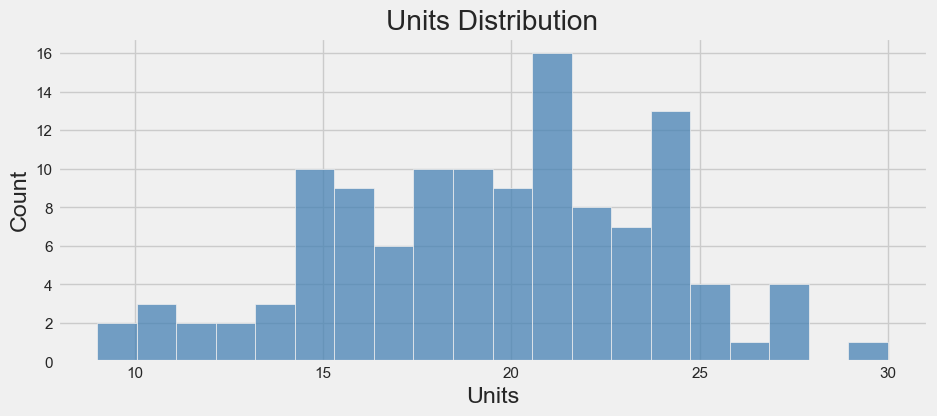

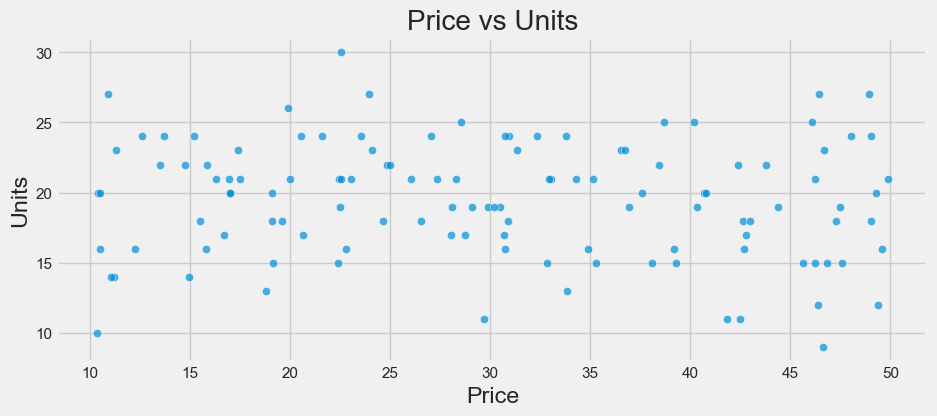

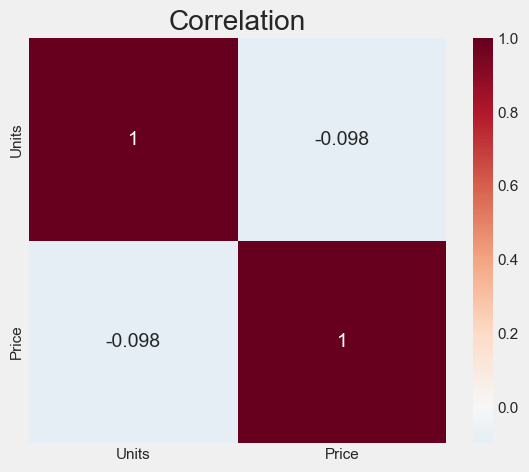

In [8]:
np.random.seed(1)
dates = pd.date_range('2024-01-01', periods=120, freq='D')
regions = np.random.choice(['North','South','East','West'], size=120)
products = np.random.choice(['A','B','C'], size=120)
units = np.random.poisson(lam=20, size=120)
price = np.random.uniform(10, 50, size=120).round(2)
sales = pd.DataFrame({'Date': dates, 'Region': regions, 'Product': products, 'Units': units, 'Price': price})
sales.to_csv('practice_sales.csv', index=False)

sales_df = pd.read_csv('practice_sales.csv')
print(sales_df.head())
print('Describe:')
print(sales_df.describe())

plt.figure(figsize=(10,4)); sns.histplot(sales_df['Units'], bins=20, color='steelblue'); plt.title('Units Distribution'); plt.show()

plt.figure(figsize=(10,4)); sns.scatterplot(x='Price', y='Units', data=sales_df, alpha=0.7); plt.title('Price vs Units'); plt.show()

plt.figure(figsize=(6,5)); sns.heatmap(sales_df[['Units','Price']].corr(), annot=True, cmap='RdBu_r', center=0); plt.title('Correlation'); plt.show()


#### Exercise 1 Explanation
EDA inspects distributions and relationships. The histogram shows how `Units` vary; the scatter plot reveals the association between `Price` and `Units`; the correlation heatmap quantifies the linear relationship between the two numeric variables.


### Exercise 2: Clean missing values, encode categories, scale numerics
Goal: practice data cleaning and preprocessing for modeling.
Steps: introduce some NaNs, impute, one-hot encode, and scale numeric columns.

In [9]:
sales_df.loc[sales_df.sample(frac=0.1, random_state=42).index, 'Units'] = np.nan
median_units = sales_df['Units'].median()
sales_df['Units'] = sales_df['Units'].fillna(median_units)
encoded = pd.get_dummies(sales_df, columns=['Region','Product'], drop_first=True)
num_cols = ['Units','Price']
scaler = StandardScaler()
encoded[num_cols] = scaler.fit_transform(encoded[num_cols])
print(encoded.head())


         Date     Units     Price  Region_North  Region_South  Region_West  \
0  2024-01-01  1.150241  1.497338         False          True        False   
1  2024-01-02  0.391840  1.344364         False         False         True   
2  2024-01-03 -2.136162  0.978231          True         False        False   
3  2024-01-04 -2.641763  1.376965          True         False        False   
4  2024-01-05  0.139040 -1.196838         False         False         True   

   Product_B  Product_C  
0      False      False  
1       True      False  
2       True      False  
3       True      False  
4      False      False  


#### Exercise 2 Explanation
Median imputation replaces missing `Units` with a robust central value. One-hot encoding converts categorical `Region` and `Product` into numeric indicators without imposing ordinality. Standardization centers and scales numeric features, improving performance for distance-based models.


### Exercise 3: Train a KNN classifier; tune k with cross-validation
Goal: build a classifier and see how `k` affects accuracy.
Steps: use iris, pipeline with scaling, and loop over k to compute CV accuracy.

In [10]:
iris = sns.load_dataset('iris')
X_cls = iris.drop(columns=['species'])
y_cls = iris['species']
le = LabelEncoder()
y_cls_enc = le.fit_transform(y_cls)
results = []
for k in [3,5,7,9,11]:
    pipe_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe_knn, X_cls, y_cls_enc, cv=5, scoring='accuracy')
    results.append((k, scores.mean(), scores.std()))
print('k, mean accuracy, std:')
for r in results:
    print(r)


k, mean accuracy, std:
(3, np.float64(0.9533333333333334), np.float64(0.03399346342395189))
(5, np.float64(0.96), np.float64(0.024944382578492935))
(7, np.float64(0.96), np.float64(0.03265986323710903))
(9, np.float64(0.96), np.float64(0.03265986323710903))
(11, np.float64(0.9466666666666665), np.float64(0.03399346342395189))


#### Exercise 3 Explanation
Cross-validation estimates generalization. Smaller `k` tends to fit local noise (overfit), larger `k` smooths decision boundaries (potential underfit). The reported mean accuracy across folds helps select a balanced `k`.


### Exercise 4: Fit Linear Regression; report R² and RMSE
Goal: practice supervised regression evaluation.
Steps: use a standard dataset (diabetes), fit, predict, compute metrics.

In [11]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
X_reg = data.data
y_reg = data.target
Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
lr = LinearRegression().fit(Xtr, ytr)
yp = lr.predict(Xte)
print('R2:', round(r2_score(yte, yp), 3))
print('RMSE:', np.sqrt(mean_squared_error(yte, yp)).round(3))


R2: 0.453
RMSE: 53.853


#### Exercise 4 Explanation
R² indicates the proportion of target variance explained by the model; RMSE is the average magnitude of prediction error. Together they summarize fit quality and error scale on the test set.


### Exercise 5: Apply PCA and plot explained variance
Goal: reduce dimensions and understand variance captured.
Steps: standardize features, fit PCA, plot a scree chart of variance ratios.

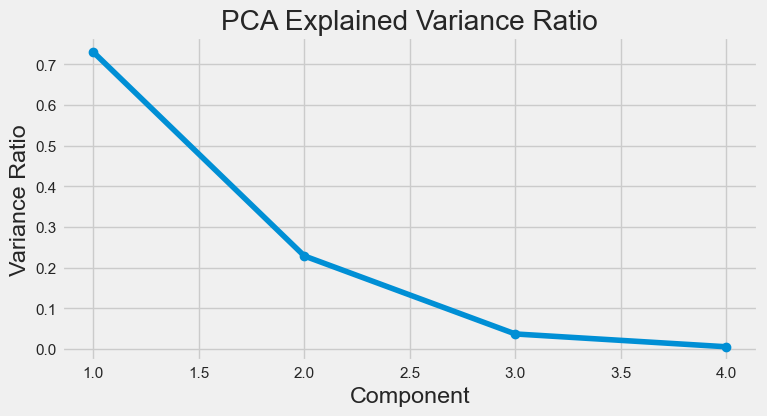

In [12]:
X_cls2 = iris.drop(columns=['species']) if 'iris' in globals() else sns.load_dataset('iris').drop(columns=['species'])
X_std2 = StandardScaler().fit_transform(X_cls2)
pca_full = PCA().fit(X_std2)
var_ratio = pca_full.explained_variance_ratio_
plt.figure(figsize=(8,4)); plt.plot(np.arange(1, len(var_ratio)+1), var_ratio, marker='o'); plt.title('PCA Explained Variance Ratio'); plt.xlabel('Component'); plt.ylabel('Variance Ratio'); plt.show()


#### Exercise 5 Explanation
The scree plot shows how much variance each principal component explains. A sharp drop suggests a natural cutoff; retaining the top components captures most structure while reducing dimensionality.


### Exercise 6: Cluster with K-Means and interpret clusters
Goal: perform unsupervised clustering and relate clusters to known labels.
Steps: cluster standardized iris features and compare cluster labels to species via crosstab.

In [13]:
iris_df = sns.load_dataset('iris') if 'iris' not in globals() else iris
X_std2b = StandardScaler().fit_transform(iris_df.drop(columns=['species']))
kmeans2 = KMeans(n_clusters=3, random_state=0)
labels2 = kmeans2.fit_predict(X_std2b)
ct = pd.crosstab(pd.Series(labels2, name='Cluster'), pd.Series(iris_df['species'], name='Species'))
print(ct)


Species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36


#### Exercise 6 Explanation
The crosstab aligns discovered clusters with species labels. Strong diagonal counts indicate clusters correspond well to true classes; mixed counts imply overlap or non-spherical clusters.


### Exercise 7: Create a time series, resample weekly, compute a rolling mean
Goal: practice time series resampling and smoothing.
Steps: generate daily data, resample to weekly mean, compute and plot a rolling mean.

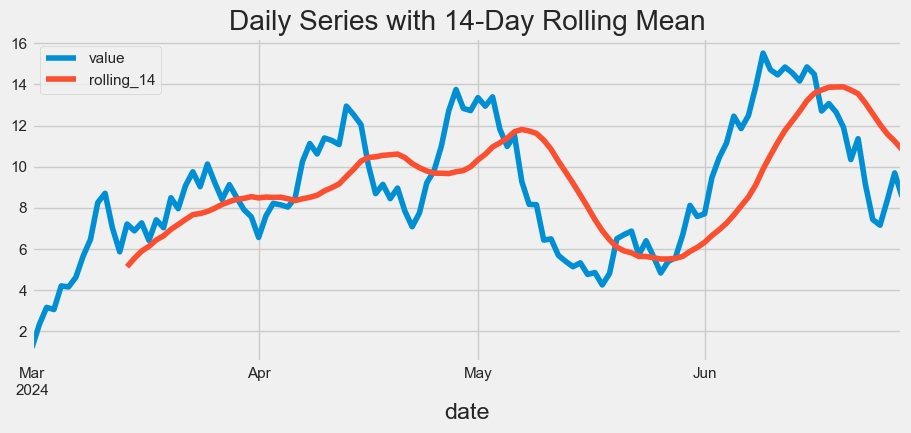

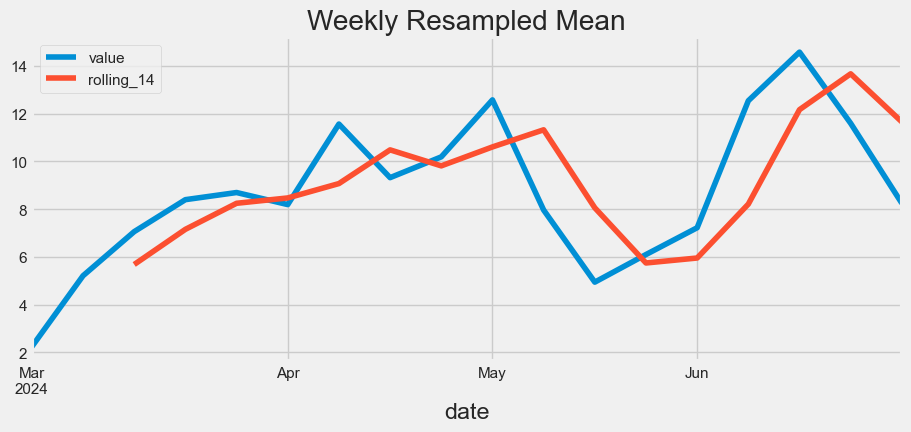

In [14]:
dates2 = pd.date_range('2024-03-01', periods=120, freq='D')
vals2 = pd.Series(np.random.randn(120).cumsum())
ts2 = pd.DataFrame({'date': dates2, 'value': vals2}).set_index('date')
ts2['rolling_14'] = ts2['value'].rolling(14).mean()
ts2_resamp = ts2.resample('W').mean()
ts2.plot(figsize=(10,4)); plt.title('Daily Series with 14-Day Rolling Mean'); plt.show()
ts2_resamp.plot(figsize=(10,4)); plt.title('Weekly Resampled Mean'); plt.show()


#### Exercise 7 Explanation
Rolling means smooth short-term noise, revealing underlying trends; weekly resampling aggregates daily observations to a coarser cadence. Comparing both views helps distinguish signal from noise.


## End-Semester Exam-Style Questions (10) with Solutions
The following questions simulate exam tasks. Each includes a solution and an explanation.

### Q1: Stratified CV with Logistic Regression on Iris
Compute 5-fold stratified cross-validated macro F1 using a pipeline (scaling + logistic regression).

In [15]:
from sklearn.model_selection import StratifiedKFold
iris_q = sns.load_dataset('iris')
Xq1 = iris_q.drop(columns=['species'])
yq1 = iris_q['species']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_q1 = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(max_iter=1000))])
cv_q1 = cross_val_score(pipe_q1, Xq1, yq1, cv=skf, scoring='f1_macro')
print('F1-macro (mean ± std):', cv_q1.mean().round(3), '±', cv_q1.std().round(3))


F1-macro (mean ± std): 0.953 ± 0.045


Stratification preserves class proportions across folds, yielding stable estimates. Macro F1 averages F1 across classes, emphasizing balanced performance rather than favoring the majority class.

### Q2: Chi-Square Test of Independence (Region vs Product)
Test whether `Region` and `Product` are independent using a contingency table and chi-square statistic.

In [16]:
sales_exam = pd.read_csv('practice_sales.csv')
ct = pd.crosstab(sales_exam['Region'], sales_exam['Product'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print('Chi2:', round(chi2,3), 'p:', round(p,4), 'dof:', dof)


Chi2: 2.089 p: 0.9114 dof: 6


A small p-value suggests `Region` and `Product` are associated rather than independent. The test compares observed counts to those expected under independence.

### Q3: 95% CI for Difference of Means
Estimate a 95% confidence interval for the difference of two normal means.

In [17]:
np.random.seed(0)
g1 = np.random.normal(50, 10, size=100)
g2 = np.random.normal(53, 10, size=100)
diff = g2.mean() - g1.mean()
se = math.sqrt(g1.var(ddof=1)/len(g1) + g2.var(ddof=1)/len(g2))
z = 1.96
print('Diff mean:', round(diff,3), '95% CI:', (round(diff - z*se,3), round(diff + z*se,3)))


Diff mean: 3.222 95% CI: (np.float64(0.377), np.float64(6.067))


The interval quantifies uncertainty around the mean difference. If it excludes 0, the groups differ significantly at the 5% level under normal assumptions.

### Q4: Scaling Choice Impact on KNN Accuracy
Compare StandardScaler vs MinMaxScaler for KNN classification on iris.

In [18]:
iris_s = sns.load_dataset('iris')
X_s = iris_s.drop(columns=['species'])
y_s = LabelEncoder().fit_transform(iris_s['species'])
results_scaling = {}
for scaler in [MinMaxScaler(), StandardScaler()]:
    pipe_scaling = Pipeline([('scaler', scaler), ('knn', KNeighborsClassifier(n_neighbors=5))])
    scores_scaling = cross_val_score(pipe_scaling, X_s, y_s, cv=5, scoring='accuracy')
    results_scaling[type(scaler).__name__] = (scores_scaling.mean().round(3), scores_scaling.std().round(3))
print(results_scaling)


{'MinMaxScaler': (np.float64(0.96), np.float64(0.033)), 'StandardScaler': (np.float64(0.96), np.float64(0.025))}


Distance-based models depend on feature scales. Different scalers can change neighbor relationships; the comparison shows which normalization yields better accuracy for this dataset.

### Q5: K-Means Elbow Method
Use inertia across k=1..10 on standardized iris features to choose k.

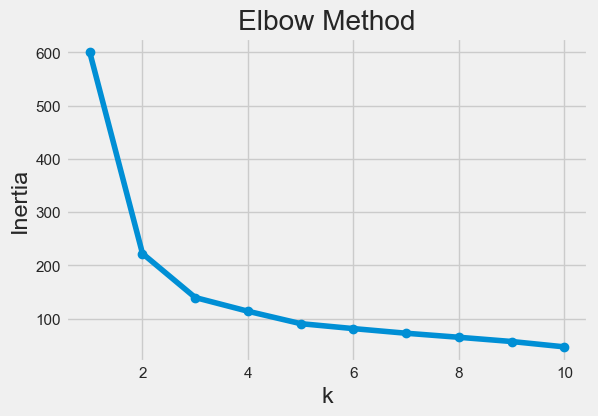

In [19]:
X_elbow = StandardScaler().fit_transform(sns.load_dataset('iris').drop(columns=['species']))
ks = range(1, 11)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_elbow)
    inertias.append(km.inertia_)
plt.figure(figsize=(6,4)); plt.plot(list(ks), inertias, marker='o'); plt.title('Elbow Method'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.show()


An elbow (sharp bend) indicates diminishing returns from adding clusters. Choosing k near the elbow balances compactness with parsimony.

### Q6: Feature Selection with SelectKBest (ANOVA F)
Evaluate accuracy for k=2,3,4 selected features using a pipeline.

In [20]:
from sklearn.feature_selection import SelectKBest, f_classif
iris_sel = sns.load_dataset('iris')
X_sel = iris_sel.drop(columns=['species'])
y_sel = LabelEncoder().fit_transform(iris_sel['species'])
for k in [2,3,4]:
    pipe_sel = Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(score_func=f_classif, k=k)), ('logreg', LogisticRegression(max_iter=1000))])
    scores_sel = cross_val_score(pipe_sel, X_sel, y_sel, cv=5, scoring='accuracy')
    print(k, scores_sel.mean().round(3), scores_sel.std().round(3))


2 0.96 0.025
3 0.96 0.025
4 0.96 0.039


Filter-based selection ranks features by discriminative power. The best k balances information retention and noise reduction, improving classifier performance.

### Q7: PCA + Logistic Regression Tuning
Assess accuracy across PCA components 1–4 on iris using a pipeline.

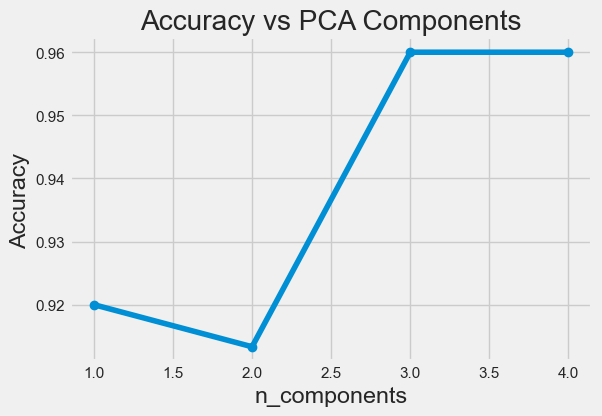

In [21]:
iris_p = sns.load_dataset('iris')
X_p = iris_p.drop(columns=['species'])
y_p = LabelEncoder().fit_transform(iris_p['species'])
comps = [1,2,3,4]
means = []
for n in comps:
    pipe_p = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n)), ('logreg', LogisticRegression(max_iter=1000))])
    scores_p = cross_val_score(pipe_p, X_p, y_p, cv=5, scoring='accuracy')
    means.append(scores_p.mean())
plt.figure(figsize=(6,4)); plt.plot(comps, means, marker='o'); plt.title('Accuracy vs PCA Components'); plt.xlabel('n_components'); plt.ylabel('Accuracy'); plt.show()


PCA can reduce noise and multicollinearity. The curve shows how dimensionality affects classification; too few components underfit, too many reintroduce noise.

### Q8: Autocorrelation of a Daily Time Series
Compute and plot autocorrelation for lags 1–20 to assess temporal dependence.

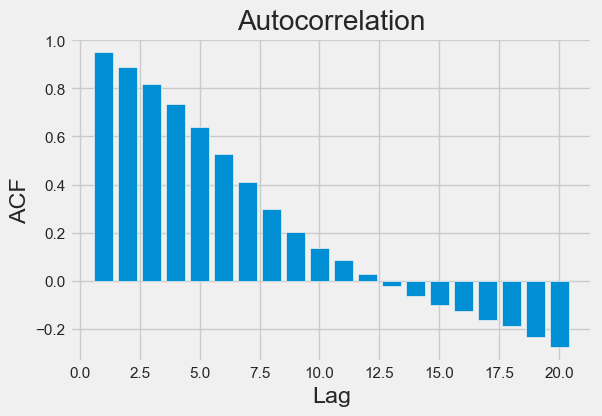

In [22]:
ts_exam = ts2 if 'ts2' in globals() else pd.DataFrame({'date': pd.date_range('2024-03-01', periods=120, freq='D'), 'value': pd.Series(np.random.randn(120).cumsum())}).set_index('date')
lags = range(1, 21)
acfs = [ts_exam['value'].autocorr(lag=l) for l in lags]
plt.figure(figsize=(6,4)); plt.bar(list(lags), acfs); plt.title('Autocorrelation'); plt.xlabel('Lag'); plt.ylabel('ACF'); plt.show()


High autocorrelation at small lags indicates persistence; near-zero values suggest weak temporal dependence. Patterns inform smoothing and forecasting choices.

### Q9: ROC Curve for KNN (Binary Setosa vs Others)
Train KNN with scaling and plot ROC; report AUC.

In [23]:
iris_b = sns.load_dataset('iris')
X_b = iris_b.drop(columns=['species'])
y_b = (iris_b['species'] == 'setosa').astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)
pipe_b = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe_b.fit(X_train_b, y_train_b)
probs_b = pipe_b.predict_proba(X_test_b)[:,1]
fpr_b, tpr_b, _ = roc_curve(y_test_b, probs_b)
auc_b = roc_auc_score(y_test_b, probs_b)
print('ROC-AUC:', auc_b.round(3))
plt.figure(figsize=(6,4)); plt.plot(fpr_b, tpr_b); plt.plot([0,1],[0,1],'k--'); plt.title('KNN ROC'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.show()


AttributeError: 'float' object has no attribute 'round'

AUC summarizes ranking quality across thresholds. Curves above the diagonal indicate discriminatory power; higher AUC reflects better separability of setosa vs others.

### Q10: CV R² for Scaled Linear Regression (Diabetes)
Evaluate 5-fold cross-validated R² using a pipeline.

In [ ]:
from sklearn.datasets import load_diabetes
X_d = load_diabetes().data
y_d = load_diabetes().target
pipe_d = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
scores_d = cross_val_score(pipe_d, X_d, y_d, cv=5, scoring='r2')
print('CV R2 (mean ± std):', scores_d.mean().round(3), '±', scores_d.std().round(3))


Cross-validated R² estimates generalization for regression. Scaling helps stabilize coefficient estimation; the mean and spread across folds indicate model reliability.